# Single User Downlink Power Optimization

This notebook splits the analysis into two complementary studies using the shared single-user engine:
a rate sweep at a fixed 400 m link distance, and a distance sweep from 50 m to 500 m for a fixed
300 Mbps requirement.


## 1. Imports


In [1]:
import os
import sys
from pathlib import Path
from itertools import product

import matplotlib
matplotlib.use("Agg")
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

sys.path.insert(0, str((Path.cwd() / "src").resolve()))

NOTEBOOK_OUTER_PARALLEL = True
NOTEBOOK_MAX_WORKERS = max(1, os.cpu_count() or 1)

from single_user_study import (
    search_candidates,
    build_single_user_pa_curve_table,
    build_single_user_plot_domains,
    build_single_user_scenario,
    run_distance_study,
    run_rate_study,
    summarize_single_user_scenario,
)


## 2. Explicit Inputs


In [2]:
rate_required_targets_bps = np.linspace(1e6, 300e6, 100)
distance_values_m = np.arange(50.0, 500.0 + 25.0, 25.0).tolist()

rate_study_config = {
    "study_name": "rate",
    "distance_m": 400.0,
    "rate_targets_bps": rate_required_targets_bps.tolist(),
}

distance_study_config = {
    "study_name": "distance",
    "distance_values_m": distance_values_m,
    "rate_target_bps": 250e6,
}

reference_scenario = build_single_user_scenario(
    distance_m=float(rate_study_config["distance_m"]),
    required_rate_bps=float(np.min(rate_required_targets_bps)),
)
reference_search_result = search_candidates(
    distance_m=float(rate_study_config["distance_m"]),
    required_rate_bps=float(np.min(rate_required_targets_bps)),
)
reference_search_views = summarize_single_user_scenario(reference_scenario)
search_space_detail = reference_search_views["search_space_detail"].iloc[0]
pa_characteristics = reference_search_views["pa_characteristics"]

print(f"Rate study fixed distance (m): {rate_study_config['distance_m']:.0f}")
print(
    "Rate study target rates (Mbps):",
    [round(float(v) / 1e6, 1) for v in rate_study_config["rate_targets_bps"]],
)
print(f"Distance study fixed target (Mbps): {distance_study_config['rate_target_bps'] / 1e6:.0f}")
print(f"Distance study distances (m): {distance_study_config['distance_values_m']}")
print(
    "Bandwidth space (MHz):",
    [float(v) / 1e6 for v in search_space_detail["bandwidth_space_hz"]],
)
print(f"Layer space: {list(search_space_detail['layers_space'])}")
print(
    f"MCS range: {int(search_space_detail['mcs_min'])}..{int(search_space_detail['mcs_max'])} | "
    f"PRB step: {int(search_space_detail['prb_step'])}"
)


Rate study fixed distance (m): 400
Rate study target rates (Mbps): [1.0, 4.0, 7.0, 10.1, 13.1, 16.1, 19.1, 22.1, 25.2, 28.2, 31.2, 34.2, 37.2, 40.3, 43.3, 46.3, 49.3, 52.3, 55.4, 58.4, 61.4, 64.4, 67.4, 70.5, 73.5, 76.5, 79.5, 82.5, 85.6, 88.6, 91.6, 94.6, 97.6, 100.7, 103.7, 106.7, 109.7, 112.7, 115.8, 118.8, 121.8, 124.8, 127.8, 130.9, 133.9, 136.9, 139.9, 142.9, 146.0, 149.0, 152.0, 155.0, 158.1, 161.1, 164.1, 167.1, 170.1, 173.2, 176.2, 179.2, 182.2, 185.2, 188.3, 191.3, 194.3, 197.3, 200.3, 203.4, 206.4, 209.4, 212.4, 215.4, 218.5, 221.5, 224.5, 227.5, 230.5, 233.6, 236.6, 239.6, 242.6, 245.6, 248.7, 251.7, 254.7, 257.7, 260.7, 263.8, 266.8, 269.8, 272.8, 275.8, 278.9, 281.9, 284.9, 287.9, 290.9, 294.0, 297.0, 300.0]
Distance study fixed target (Mbps): 250
Distance study distances (m): [50.0, 75.0, 100.0, 125.0, 150.0, 175.0, 200.0, 225.0, 250.0, 275.0, 300.0, 325.0, 350.0, 375.0, 400.0, 425.0, 450.0, 475.0, 500.0]
Bandwidth space (MHz): [50.0, 100.0]
Layer space: [1, 2, 4]
MCS ra

## 3. Shared Engine


In [3]:
print(f"PA models: {len(pa_characteristics)}")
print(f"PA names: {sorted(pa_characteristics['pa_name'].tolist())}")
print(f"MCS entries: {int(search_space_detail['mcs_entry_count'])}")


PA models: 2
PA names: ['Bae et al. NR', 'QPA9942']
MCS entries: 29


## 4. Exploration Functions


In [4]:
def print_search_space_summary(search_space_summary):
    summary_row = search_space_summary.iloc[0]
    print("Search-space summary")
    print(f"- PA models: {int(summary_row['pa_count'])}")
    print(f"- Scenario points: {int(summary_row['scenario_count'])}")
    print(f"- Raw configs per PA per scenario: {int(summary_row['raw_configs_per_pa_per_scenario']):,}")
    print(f"- Raw configs per scenario across all PAs: {int(summary_row['raw_configs_per_scenario']):,}")
    print(f"- Raw total configs across full sweep: {int(summary_row['raw_total_configs']):,}")


## 5. Run The Explorations


In [5]:
rate_study = run_rate_study(
    distance_m=float(rate_study_config["distance_m"]),
    rate_targets_bps=rate_study_config["rate_targets_bps"],
    outer_parallel=NOTEBOOK_OUTER_PARALLEL,
    max_workers=NOTEBOOK_MAX_WORKERS,
)
distance_study = run_distance_study(
    distance_values_m=distance_study_config["distance_values_m"],
    required_rate_bps=float(distance_study_config["rate_target_bps"]),
    outer_parallel=NOTEBOOK_OUTER_PARALLEL,
    max_workers=NOTEBOOK_MAX_WORKERS,
)

print_search_space_summary(rate_study.search_space_summary)
print_search_space_summary(distance_study.search_space_summary)

rate_frontier_table = rate_study.frontier_table
rate_explanatory_configs = rate_study.explanatory_configs
distance_frontier_table = distance_study.frontier_table
distance_explanatory_configs = distance_study.explanatory_configs
pa_characteristics = rate_study.pa_characteristics


Search-space summary
- PA models: 2
- Scenario points: 1
- Raw configs per PA per scenario: 389,760
- Raw configs per scenario across all PAs: 779,520
- Raw total configs across full sweep: 779,520
Search-space summary
- PA models: 2
- Scenario points: 19
- Raw configs per PA per scenario: 389,760
- Raw configs per scenario across all PAs: 779,520
- Raw total configs across full sweep: 14,810,880


## 6. PA Characteristics


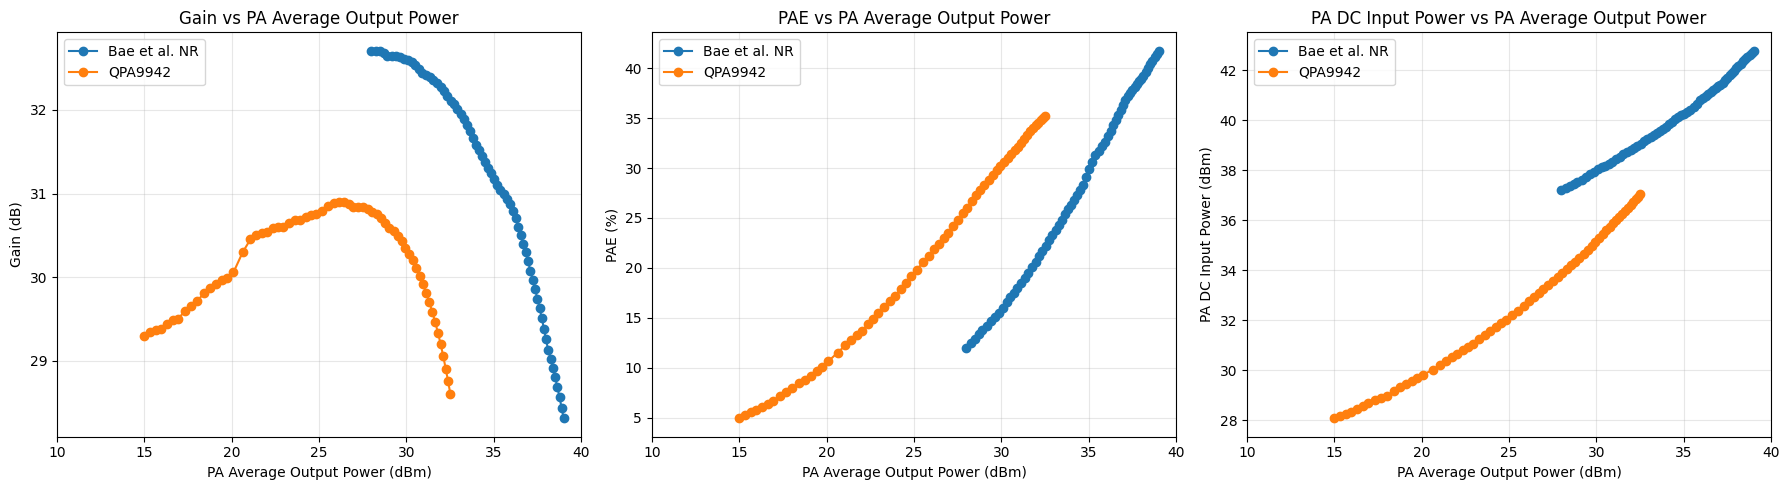

In [6]:
fig_pa_sanity, axes = plt.subplots(1, 3, figsize=(18, 5))

pout_min_dbm, pout_max_dbm = np.inf, -np.inf
pa_curve_table = build_single_user_pa_curve_table(reference_scenario)

for pa_name, pa_curve_rows in pa_curve_table.groupby("pa_name", sort=True):
    pout_w = pa_curve_rows["pout_w"].to_numpy(dtype=float)
    pin_w = pa_curve_rows["pin_w"].to_numpy(dtype=float)
    pdc_w = pa_curve_rows["pdc_w"].to_numpy(dtype=float)

    pout_dbm = 10 * np.log10(pout_w * 1000.0)
    pin_dbm = 10 * np.log10(pin_w * 1000.0)
    pdc_dbm = 10 * np.log10(pdc_w * 1000.0)

    gain_db = pout_dbm - pin_dbm
    pae_percent = 100.0 * (pout_w - pin_w) / pdc_w

    pout_min_dbm = min(pout_min_dbm, np.min(pout_dbm))
    pout_max_dbm = max(pout_max_dbm, np.max(pout_dbm))

    axes[0].plot(
        pout_dbm,
        gain_db,
        marker="o",
        label=pa_name,
    )
    axes[1].plot(
        pout_dbm,
        pae_percent,
        marker="o",
        label=pa_name,
    )
    axes[2].plot(
        pout_dbm,
        pdc_dbm,
        marker="o",
        label=pa_name,
    )

axes[0].set_title("Gain vs PA Average Output Power")
axes[1].set_title("PAE vs PA Average Output Power")
axes[2].set_title("PA DC Input Power vs PA Average Output Power")

for ax in axes:
    ax.set_xlabel("PA Average Output Power (dBm)")
    ax.set_xlim(10, 40)
    ax.grid(True, alpha=0.3)
    ax.legend()

axes[0].set_ylabel("Gain (dB)")
axes[1].set_ylabel("PAE (%)")
axes[2].set_ylabel("PA DC Input Power (dBm)")

plt.tight_layout()
plt.show()


## 7. Frontier Plots


In [7]:
%matplotlib inline

pa_label_map = pa_characteristics.set_index("pa_id")["pa_name"].to_dict()
marker_sequence = ["x", "o", "^", "D", "v", "P", "*", "+", ".", "s"]


def build_style_maps(pa_ids):
    size_max = 50
    size_min = 20
    sizes = np.linspace(size_max, size_min, len(pa_ids))
    pa_marker_map = {pa_id: marker_sequence[i % len(marker_sequence)] for i, pa_id in enumerate(pa_ids)}
    pa_size_map = {pa_id: sizes[i] for i, pa_id in enumerate(pa_ids)}
    return pa_marker_map, pa_size_map


def prep(df, x_col):
    return df.sort_values(x_col)


def req_snr_db(series):
    gamma = np.asarray(pd.to_numeric(series, errors="coerce"), dtype=float)
    return 10.0 * np.log10(np.clip(gamma, 1e-12, None))


def round_up_to_step(value, step):
    value = float(value)
    step = float(step)
    if value <= 0.0:
        return step
    return step * np.ceil(value / step)


def build_axis_from_series(values, tick_step, upper_round_step, axis_min=0.0):
    values = np.asarray(pd.to_numeric(values, errors="coerce"), dtype=float)
    finite_values = values[np.isfinite(values)]
    if finite_values.size == 0:
        axis_upper = axis_min + float(upper_round_step)
    else:
        axis_upper = round_up_to_step(max(float(finite_values.max()), float(axis_min)), upper_round_step)
    tick_values = np.arange(float(axis_min), axis_upper + 0.5 * float(tick_step), float(tick_step))
    return tick_values, (float(axis_min), float(axis_upper))


plot_domains = build_single_user_plot_domains(reference_scenario)
SUMMARY_PLOT_DOMAINS = {
    key: value
    for key, value in plot_domains.items()
    if key != "frame_slot_count"
}
FRAME_SLOT_COUNT = int(plot_domains["frame_slot_count"])


def plot_frontier_summary(frontier_table, x_col, x_label, title_prefix, figure_title, x_ticks, x_limits=None):
    assert not frontier_table.empty, f"No frontier rows found for {title_prefix.lower()} plot."

    pa_ids = sorted(frontier_table["pa_id"].unique())
    pa_marker_map, pa_size_map = build_style_maps(pa_ids)

    def format_axis(ax):
        ax.set_xlabel(x_label)
        ax.grid(True)
        if x_limits is not None:
            ax.set_xlim(*x_limits)
        ax.set_xticks(x_ticks)

    def format_discrete_axis(ax, domain_key):
        axis_config = SUMMARY_PLOT_DOMAINS[domain_key]
        ax.set_ylim(*axis_config["limits"])
        ax.set_yticks(axis_config["ticks"])

    fig, axes = plt.subplots(3, 3, figsize=(17, 12))
    fig.suptitle(figure_title, fontsize=14)

    ax = axes[0, 0]
    for pa_id in pa_ids:
        df = prep(frontier_table[frontier_table["pa_id"] == pa_id], x_col)
        ax.plot(df[x_col], df["p_dc_avg_total_w"], label=pa_label_map.get(pa_id, f"PA{pa_id}"))
    format_axis(ax)
    ax.set_ylabel("Window-Averaged Total PA DC Power (W)")
    ax.set_title(f"{title_prefix} vs Window-Averaged PA DC Power")

    ax = axes[0, 1]
    for pa_id in pa_ids:
        df = prep(frontier_table[frontier_table["pa_id"] == pa_id], x_col)
        ax.plot(df[x_col], df["p_out_total_w"], linestyle="--")
    format_axis(ax)
    ax.set_ylabel("Total PA Output Power (W)")
    ax.set_title(f"{title_prefix} vs Total PA Output Power")

    ax = axes[0, 2]
    for pa_id in pa_ids:
        df = prep(frontier_table[frontier_table["pa_id"] == pa_id], x_col)
        ax.plot(df[x_col], df["ps_total_w"] * 1000.0)
    format_axis(ax)
    ax.set_ylabel("Required PA Drive Power (mW)")
    ax.set_title(f"{title_prefix} vs Required PA Drive Power")

    ax = axes[1, 0]
    for pa_id in pa_ids:
        df = prep(frontier_table[frontier_table["pa_id"] == pa_id], x_col)
        ax.scatter(df[x_col], df["layers"], marker=pa_marker_map[pa_id], s=pa_size_map[pa_id], label=pa_label_map.get(pa_id, f"PA{pa_id}"))
    format_axis(ax)
    format_discrete_axis(ax, "layers")
    ax.set_ylabel("Layers")
    ax.set_title(f"{title_prefix} vs Layers")

    ax = axes[1, 1]
    for pa_id in pa_ids:
        df = prep(frontier_table[frontier_table["pa_id"] == pa_id], x_col)
        ax.scatter(df[x_col], df["mcs"], marker=pa_marker_map[pa_id], s=pa_size_map[pa_id])
    format_axis(ax)
    format_discrete_axis(ax, "mcs")
    ax.set_ylabel("MCS Index")
    ax.set_title(f"{title_prefix} vs MCS Index")

    ax = axes[1, 2]
    for pa_id in pa_ids:
        df = prep(frontier_table[frontier_table["pa_id"] == pa_id], x_col)
        ax.scatter(df[x_col], df["n_prb"], marker=pa_marker_map[pa_id], s=pa_size_map[pa_id])
    format_axis(ax)
    format_discrete_axis(ax, "n_prb")
    ax.set_ylabel("Allocated PRBs")
    ax.set_title(f"{title_prefix} vs Allocated PRBs")

    ax = axes[2, 0]
    for pa_id in pa_ids:
        df = prep(frontier_table[frontier_table["pa_id"] == pa_id], x_col)
        ax.scatter(df[x_col], df["n_slots_on"], marker=pa_marker_map[pa_id], s=pa_size_map[pa_id])
    format_axis(ax)
    format_discrete_axis(ax, "n_slots_on")
    ax.set_ylabel(f"Allocated Slots per {FRAME_SLOT_COUNT}-Slot Frame")
    ax.set_title(f"{title_prefix} vs Allocated Slots per Frame")

    ax = axes[2, 1]
    for pa_id in pa_ids:
        df = prep(frontier_table[frontier_table["pa_id"] == pa_id], x_col)
        ax.plot(df[x_col], req_snr_db(df["gamma_req_lin"]))
    format_axis(ax)
    ax.set_ylabel("Required SNR (dB)")
    ax.set_title(f"{title_prefix} vs Required SNR")

    ax = axes[2, 2]
    for pa_id in pa_ids:
        df = prep(frontier_table[frontier_table["pa_id"] == pa_id], x_col)
        eb = df["p_dc_avg_total_w"] / np.clip(df["rate_target_bps"], 1e-12, None)
        ax.plot(df[x_col], eb)
    format_axis(ax)
    ax.set_ylabel("PA Energy per Delivered Bit (J/bit)")
    ax.set_title(f"{title_prefix} vs Energy per Bit")
    ax.set_yscale("log")

    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=len(pa_ids), bbox_to_anchor=(0.5, 0.965))
    plt.tight_layout(rect=[0, 0, 1, 0.94])
    plt.show()
    return fig


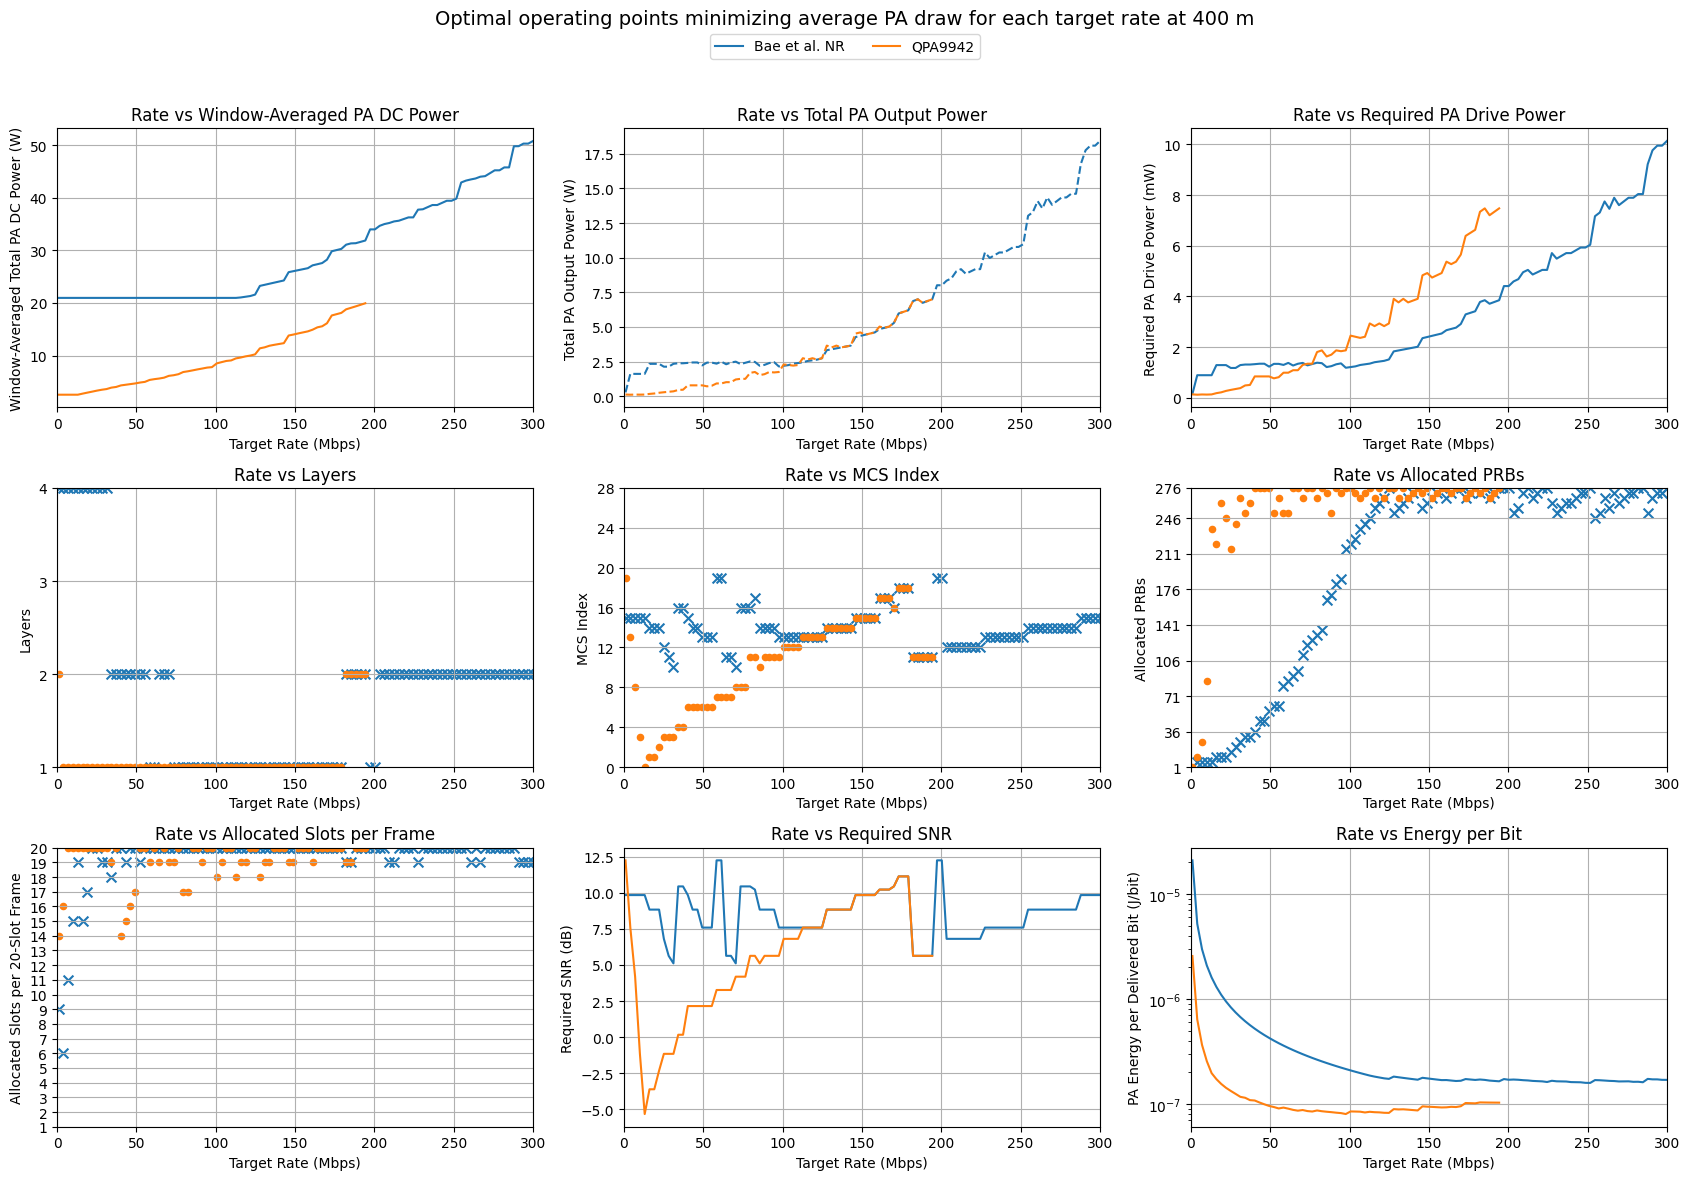

In [8]:
rate_plot_distance_m = float(rate_study_config["distance_m"])
plot_rate_frontier = rate_frontier_table.copy()
rate_tick_values, rate_limits = build_axis_from_series(
    np.asarray(rate_study_config["rate_targets_bps"], dtype=float) / 1e6,
    tick_step=50.0,
    upper_round_step=100.0,
    axis_min=0.0,
)


fig_rate_summary = plot_frontier_summary(
    frontier_table=plot_rate_frontier.assign(rate_target_mbps=plot_rate_frontier["rate_target_bps"] / 1e6),
    x_col="rate_target_mbps",
    x_label="Target Rate (Mbps)",
    title_prefix="Rate",
    figure_title=f"Optimal operating points minimizing average PA draw for each target rate at {int(rate_plot_distance_m)} m",
    x_ticks=rate_tick_values,
    x_limits=rate_limits,
)


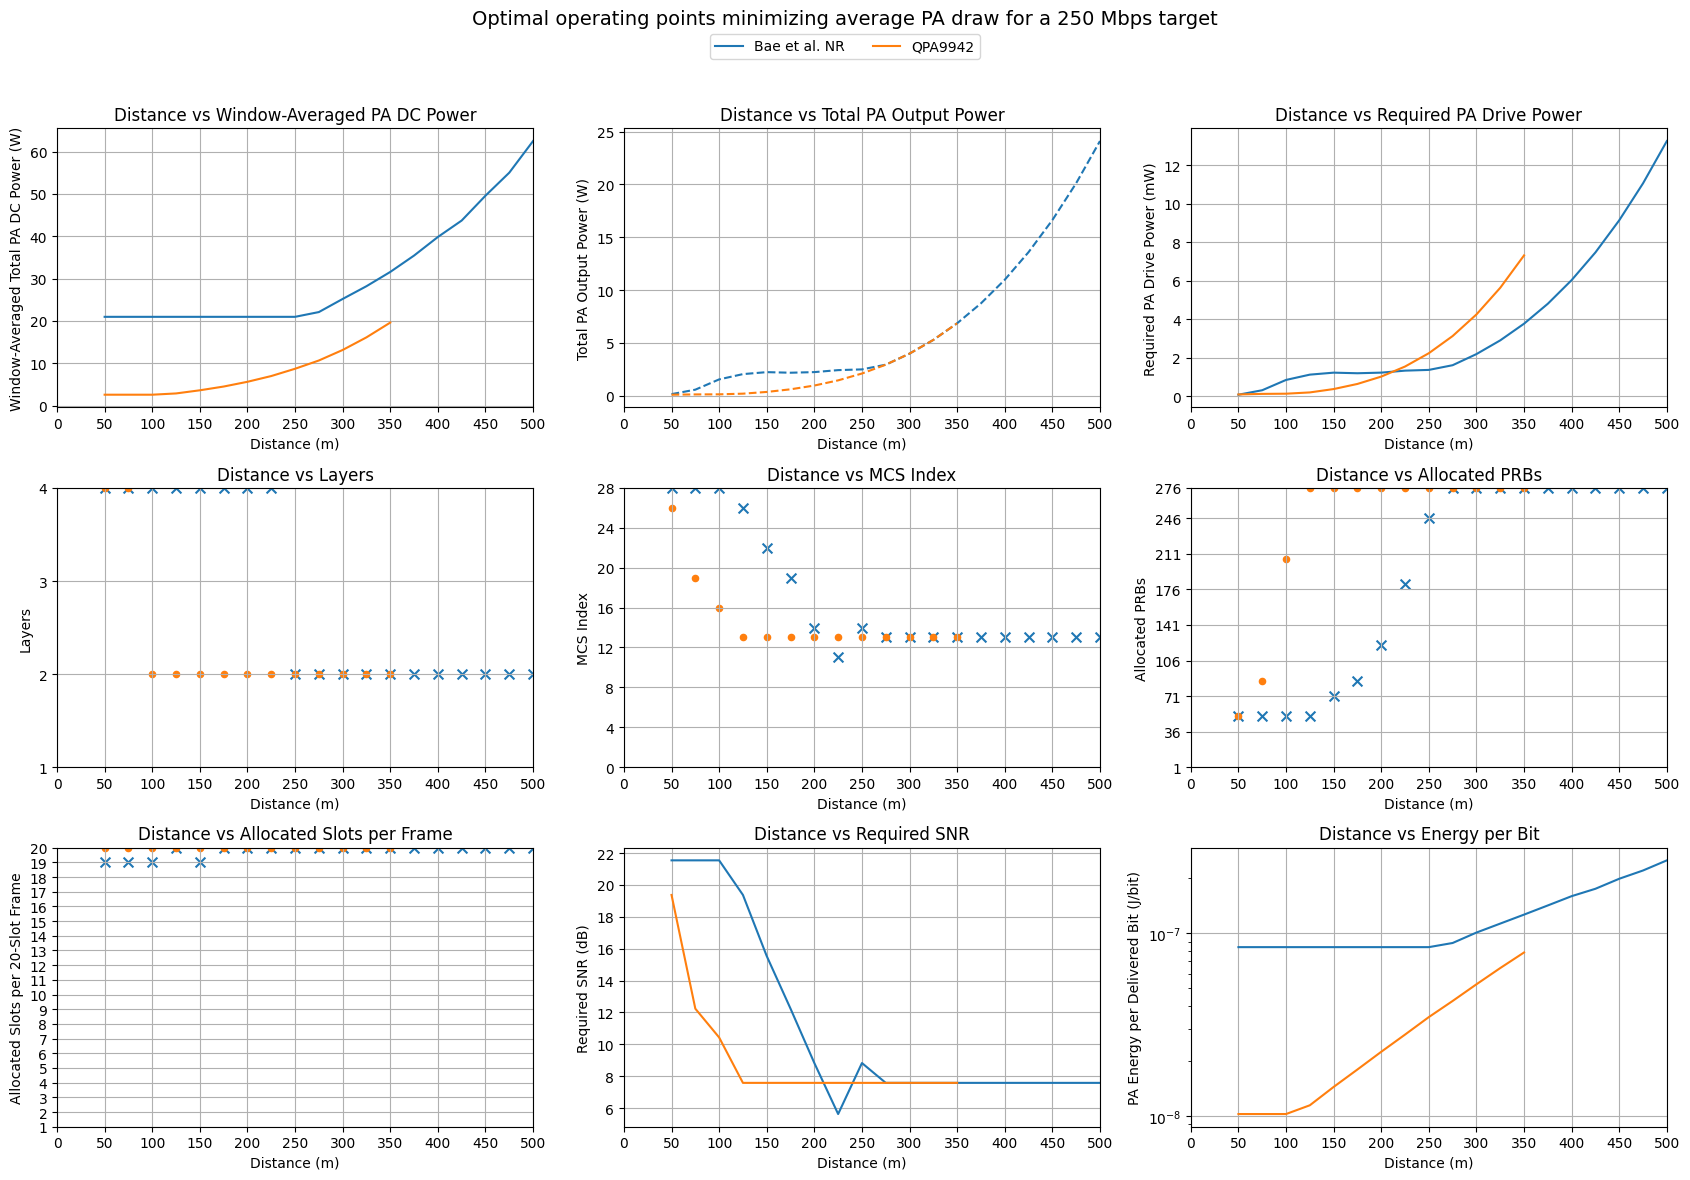

In [9]:
plot_distance_frontier = distance_frontier_table.copy()
distance_fixed_rate_mbps = float(distance_study_config["rate_target_bps"]) / 1e6
distance_tick_values, distance_limits = build_axis_from_series(
    np.asarray(distance_study_config["distance_values_m"], dtype=float),
    tick_step=50.0,
    upper_round_step=100.0,
    axis_min=0.0,
)
fig_distance_summary = plot_frontier_summary(
    frontier_table=plot_distance_frontier,
    x_col="distance_m",
    x_label="Distance (m)",
    title_prefix="Distance",
    figure_title=f"Optimal operating points minimizing average PA draw for a {distance_fixed_rate_mbps:.0f} Mbps target",
    x_ticks=distance_tick_values,
    x_limits=distance_limits,
)


## 8. Export Datasets


In [10]:
from pathlib import Path

required_objects = [
    "fig_pa_sanity",
    "fig_rate_summary",
    "fig_distance_summary",
    "rate_frontier_table",
    "distance_frontier_table",
    "pa_characteristics",
    "rate_explanatory_configs",
    "distance_explanatory_configs",
]
missing = [name for name in required_objects if name not in globals()]
assert not missing, f"Run the exploration and plot sections before saving outputs. Missing: {missing}"

graphs_dir = Path("graphs")
csv_dir = Path("csvs")
graphs_dir.mkdir(parents=True, exist_ok=True)
csv_dir.mkdir(parents=True, exist_ok=True)

image_targets = {
    "pa_characteristics.png": fig_pa_sanity,
    "rate_optimization_summary.png": fig_rate_summary,
    "distance_optimization_summary.png": fig_distance_summary,
}

for filename, fig in image_targets.items():
    fig.savefig(graphs_dir / filename, dpi=300, bbox_inches="tight")

table_targets = {
    "rate_frontier_by_pa.csv": rate_frontier_table,
    "distance_frontier_by_pa.csv": distance_frontier_table,
    "pa_characteristics.csv": pa_characteristics,
    "rate_explanatory_configs.csv": rate_explanatory_configs,
    "distance_explanatory_configs.csv": distance_explanatory_configs,
}

for filename, df in table_targets.items():
    df.to_csv(csv_dir / filename, index=False)

print(f"Saved {len(image_targets)} images to {graphs_dir.resolve()}")
print(f"Saved {len(table_targets)} tables to {csv_dir.resolve()}")


Saved 3 images to C:\Users\henry\Documents\Masters Thesis\code\graphs
Saved 5 tables to C:\Users\henry\Documents\Masters Thesis\code\csvs
